In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# データを読み込み、すべての列を数値型に変換
data = pd.read_csv("Pb_labeled.csv")

In [44]:
xdp=data['GRX']
adp=data['GRA']
ydp=data['GRY']
bdp=data['GRB']
GRQ2=data['GRQ2charge']

lx=data['LASX']

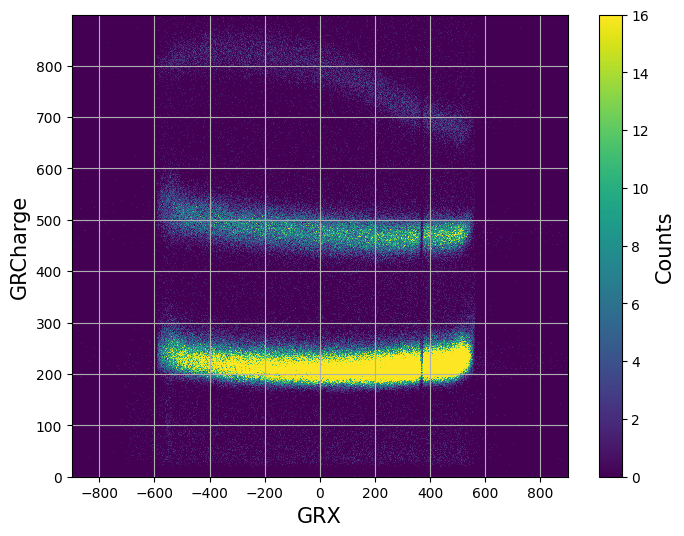

In [45]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=xdp
y_axis_variable=GRQ2
#hist range
x_axis_range_min=-900
x_axis_range_max=900
y_axis_range_min=0
y_axis_range_max=900
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 4)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts', fontsize = 15)

# 軸範囲とグリッド
ax.set_xlabel(r'GRX', fontsize = 15)
ax.set_ylabel(r'GRCharge', fontsize = 15)
ax.grid()

plt.show()

Text(0, 0.5, 'counts')

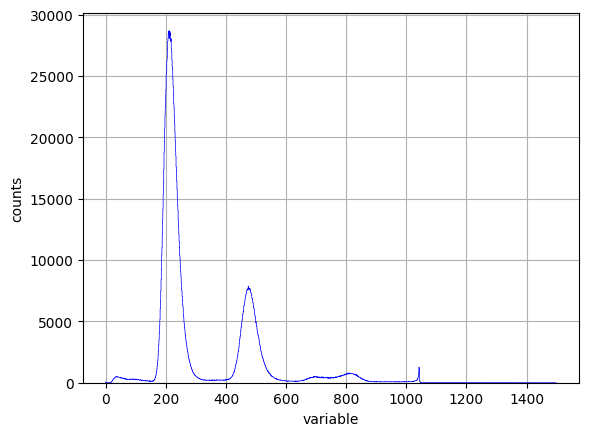

In [46]:
#トラッキングできたのを抽出

tracking_gated=data[
    (xdp != -9999) & (ydp != -9999)
]

xdp_track=tracking_gated['GRX']
adp_track=tracking_gated['GRA']
ydp_track=tracking_gated['GRY']
bdp_track=tracking_gated['GRB']
GRQ2_track=tracking_gated['GRQ2charge']


import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=GRQ2_track
#hist range
range_min=0
range_max=1500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

In [47]:
print(len(tracking_gated))
print(len(proton_gated))

2239602
1551258


Text(0, 0.5, 'counts')

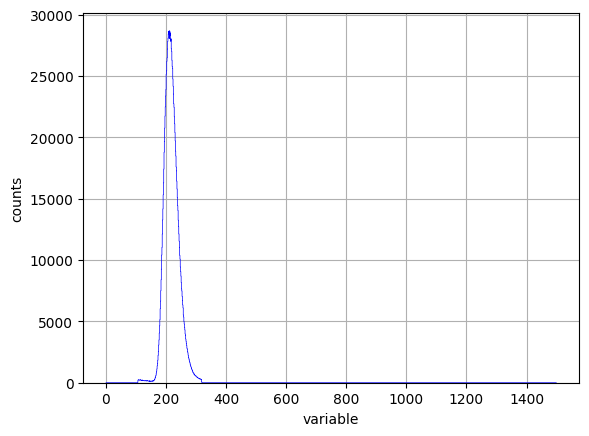

In [48]:
#プロトンゲート設定
proton_gated=tracking_gated[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5)
]

xdp_proton=proton_gated['GRX']
adp_proton=proton_gated['GRA']
ydp_proton=proton_gated['GRY']
bdp_proton=proton_gated['GRB']
GRQ2_proton=proton_gated['GRQ2charge']

import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=GRQ2_proton
#hist range
range_min=0
range_max=1500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

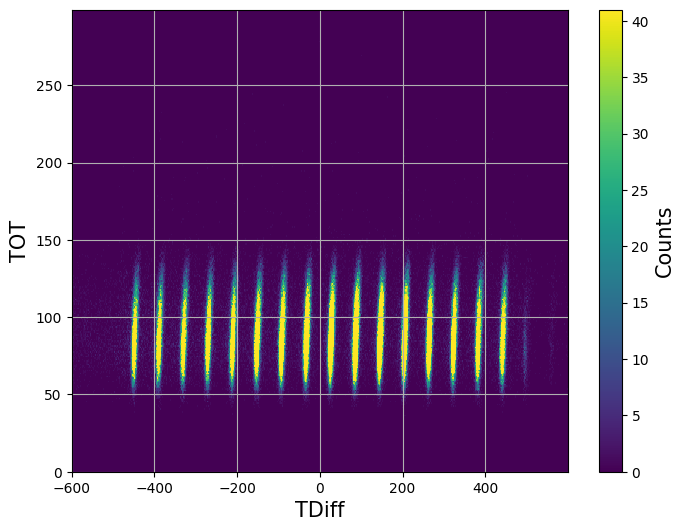

In [83]:
#input
####################################################
#variables
# x_axis_variable=proton_gated['LASQ1timing'] - proton_gated['GRQ2timing']
# y_axis_variable=proton_gated['LASTOT']


Lx = proton_gated['LASX']
TOT = proton_gated['LASTOT']

test = proton_gated[
        (TOT+0.0430496*Lx-2.0e-5*(Lx**2) > 50) & (TOT+0.0430496*Lx-2.0e-5*(Lx**2) < 130)
]
x_axis_variable=test['LASQ1timing'] - test['GRQ2timing']
y_axis_variable=test['LASTOT']


#hist range
x_axis_range_min=-600
x_axis_range_max=600
y_axis_range_min=0
y_axis_range_max=300
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 4)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts', fontsize = 15)

# 軸範囲とグリッド
ax.set_xlabel(r'TDiff', fontsize = 15)
ax.set_ylabel(r'TOT', fontsize = 15)
ax.grid()

plt.show()

In [84]:
#　コインシデンスとったやつのみ抽出
GRX_true = test['GRX']
LASX_true = test['LASX']
LASA_true = test['LASA']

Tp = (((GRX_true * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
T_alpha = 0.02746 * LASX_true + 63.804

A = -2.57
B = 1274.57

alpha = 0.02746
beta = 63.804

# LASX_true_f = LASA_true * (A * (alpha * GRX_true + beta) + B) + LASX_true
LASX_true_f = LASA_true * (A * Tp + B) + LASX_true

T_alpha_f = 0.02746 * LASX_true_f + 63.804

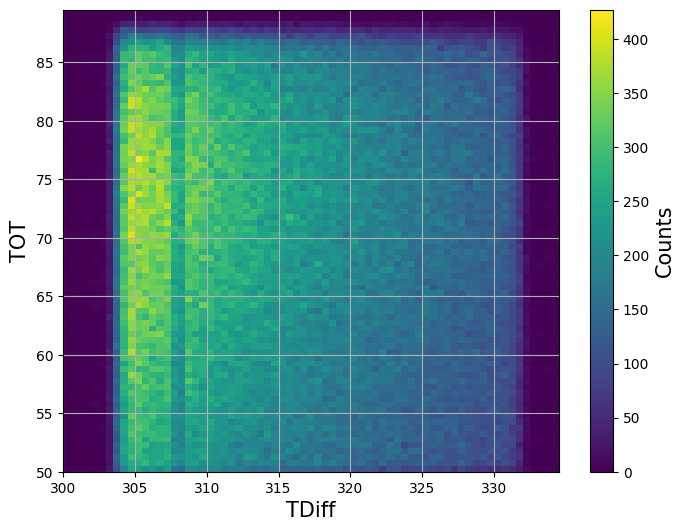

In [85]:
#input
####################################################
#variables
x_axis_variable=Tp
y_axis_variable=T_alpha_f


#hist range
x_axis_range_min=300
x_axis_range_max=335
y_axis_range_min=50
y_axis_range_max=90
#bin width
x_bin_width=0.5
y_bin_width=0.5
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 1)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts', fontsize = 15)

# 軸範囲とグリッド
ax.set_xlabel(r'TDiff', fontsize = 15)
ax.set_ylabel(r'TOT', fontsize = 15)
ax.grid()

Text(0, 0.5, 'counts')

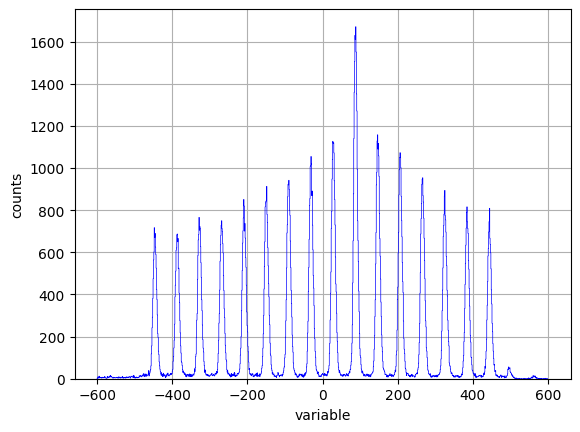

In [60]:
#input
####################################################
#variables
variable=x_axis_variable
#hist range
range_min=-600
range_max=600
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

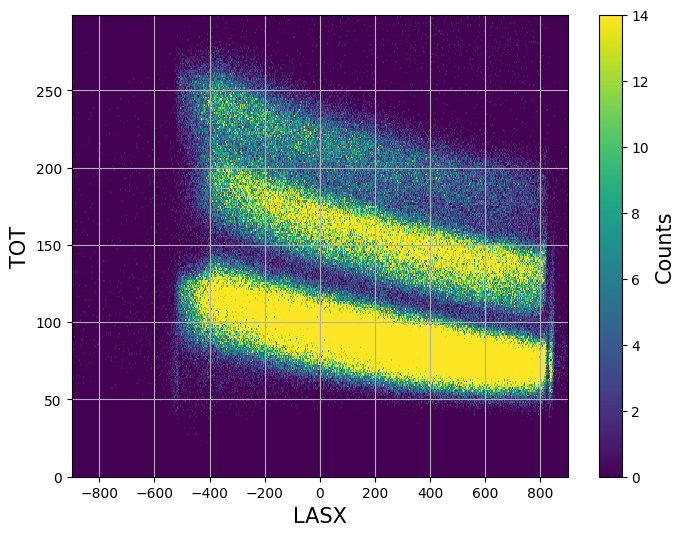

In [50]:
#input
####################################################
#variables
# x_axis_variable=proton_gated['LASX']
# y_axis_variable=proton_gated['LASTOT']
x_axis_variable=tracking_gated['LASX']
y_axis_variable=tracking_gated['LASTOT']
#hist range
x_axis_range_min=-900
x_axis_range_max=900
y_axis_range_min=0
y_axis_range_max=300
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 4)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts', fontsize = 15)

# 軸範囲とグリッド
ax.set_xlabel(r'LASX', fontsize = 15)
ax.set_ylabel(r'TOT', fontsize = 15)
ax.grid()

plt.show()

Text(0, 0.5, 'counts')

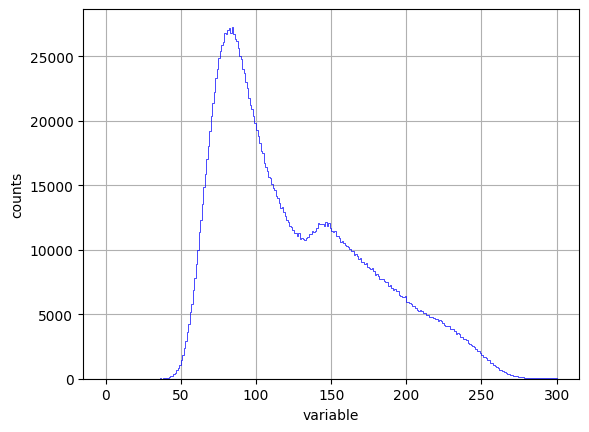

In [56]:
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=tracking_gated['LASTOT']
#hist range
range_min=0
range_max=300
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

Text(0, 0.5, 'counts')

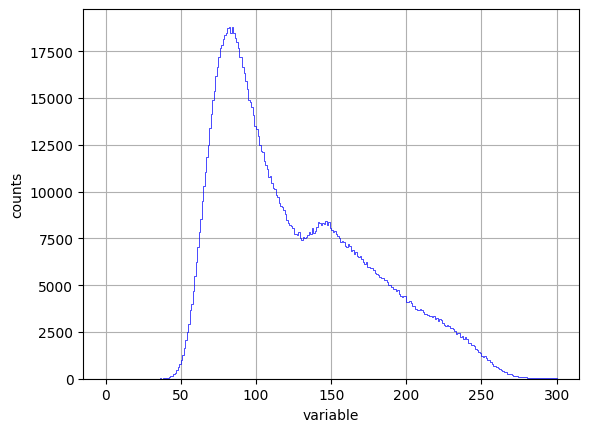

In [57]:

import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=proton_gated['LASTOT']
#hist range
range_min=0
range_max=300
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

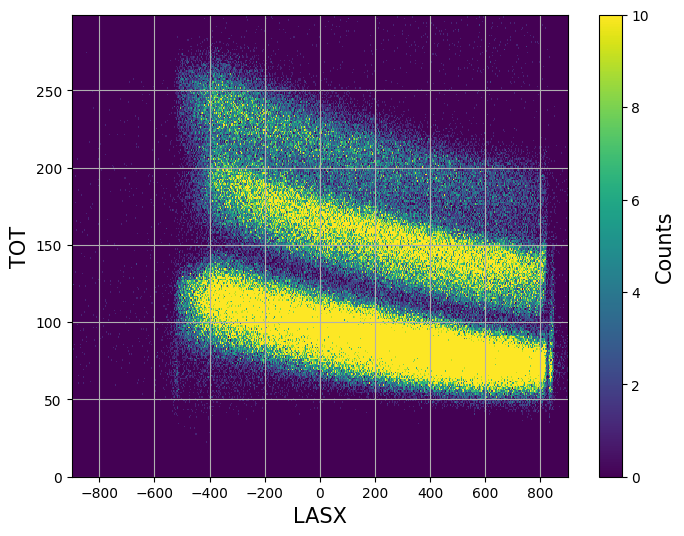

In [52]:
#input
####################################################
#variables
x_axis_variable=proton_gated['LASX']
y_axis_variable=proton_gated['LASTOT']
# x_axis_variable=tracking_gated['LASX']
# y_axis_variable=tracking_gated['LASTOT']
#hist range
x_axis_range_min=-900
x_axis_range_max=900
y_axis_range_min=0
y_axis_range_max=300
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 4)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts', fontsize = 15)

# 軸範囲とグリッド
ax.set_xlabel(r'LASX', fontsize = 15)
ax.set_ylabel(r'TOT', fontsize = 15)
ax.grid()

plt.show()

In [53]:
TDiff = tracking_gated['LASQ1timing'] - tracking_gated['GRQ2timing']
true = tracking_gated[
    (TDiff >= 50) & (TDiff < 110)
]

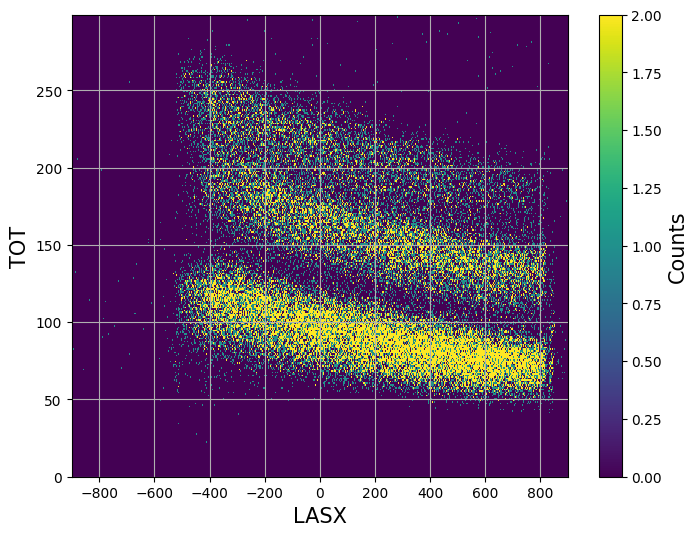

In [54]:
#input
####################################################
#variables
x_axis_variable=true['LASX']
y_axis_variable=true['LASTOT']
# x_axis_variable=tracking_gated['LASX']
# y_axis_variable=tracking_gated['LASTOT']
#hist range
x_axis_range_min=-900
x_axis_range_max=900
y_axis_range_min=0
y_axis_range_max=300
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 4)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts', fontsize = 15)

# 軸範囲とグリッド
ax.set_xlabel(r'LASX', fontsize = 15)
ax.set_ylabel(r'TOT', fontsize = 15)
ax.grid()

plt.show()